# 定義元素變異
表示法：定義每個企業創新策略元素為一個基因。  
初始群體生成：創建一個包含多個個體的初始群體，每個個體是一組隨機選擇的策略元素組合。  
適應度函數：設計一個適應度函數來評估每個個體的優良程度。可以根據一些具體指標（如市場反應、投資回報率等）來評估策略組合的優劣。  
選擇：根據適應度函數選擇一些優良個體進行交配和變異。  
交叉：對選擇的個體進行交叉操作，生成新的個體。  
變異：對一些個體進行變異操作，以引入多樣性。  
迭代：重複以上步驟多次，直到找到最優的策略組合。

使用期交所的歷史台指期資料  
存入的檔案日期當天的，漲跌是由前一天的新聞判斷  
這個方法只有判斷 yes no 沒有 unknown  

檔案說明：  
存在 out_element  


In [110]:
import os
import textwrap
import math
import pandas as pd
import numpy as np

from datetime import datetime
from dateutil.relativedelta import relativedelta

import google.generativeai as genai
from langchain.schema.messages import AIMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from google.generativeai.types import HarmBlockThreshold
from google.ai.generativelanguage_v1 import HarmCategory

from IPython.display import display
from IPython.display import Markdown

model = 'gemini-1.5-pro'
temperature = 1
top_p = 0.9
seed = 0

def to_markdown(text):
  text = text.replace('•', '  *')
  return Markdown(textwrap.indent(text, '> ', predicate=lambda _: True))

llm = ChatGoogleGenerativeAI(
                google_api_key = os.getenv('GEMINI_API_KEY'),
                model=model,
                temperature=temperature,
                top_p=top_p,
                seed=seed,
                safety_settings={
                        HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: HarmBlockThreshold.BLOCK_NONE,
                        HarmCategory.HARM_CATEGORY_HARASSMENT: HarmBlockThreshold.BLOCK_NONE,
                        HarmCategory.HARM_CATEGORY_HATE_SPEECH: HarmBlockThreshold.BLOCK_NONE,
                        HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT : HarmBlockThreshold.BLOCK_NONE,
                
            })

# path_price = os.path.join(os.path.abspath(os.path.dirname(os.getcwd())), 'history_data', 'tw', 'stock_price', id + 'tech.csv')
# path_news_title = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/tw/news_title/" + id + "news_title.json"
path_out = "out_GA_twii/"

In [111]:
# 定義策略元素字典，每個元素對應一個代號
elements = {
    "E1": "企業創新策略：企業創新的核心主題，涵蓋所有驅動企業增長和競爭力提升的策略。",
    "E2": "滿足客戶需求：企業創新的首要驅動力，能否滿足客戶需求直接影響創新成敗。",
    "E3": "吸引投資者關注：投資者的關注和信心能為企業提供必要的資金和支持，是創新成功的重要標誌。",
    "E4": "市場需求與趨勢：市場需求的變化和行業趨勢是影響企業股票表現的關鍵因素，企業需適應並預測市場變化。",
    "E5": "財務表現：穩定且增長的收入、利潤和現金流是吸引投資者的主要因素，能增加投資者信心，推動股價上漲。",
    "E6": "技術進步與研發投入：持續的技術創新和研發投入能提高企業競爭力和市場地位，促進企業長期增長。",
    "E7": "經營效率：有效的經營管理能提高企業盈利能力，進而提升股票價值。",
    "E8": "品牌聲譽與市場認可度：良好的品牌聲譽和市場認可度能增加企業產品的市場需求，促進銷售增長。",
    "E9": "政策與法規支持：政府政策和法規對行業的支持或限制會直接影響企業的發展前景和市場表現。",
    "E10": "競爭優勢與市場份額：企業在市場中的競爭優勢和市場份額的提升能增強其市場地位，吸引更多投資者。",
    "E11": "全球化與國際市場拓展：進入國際市場並擴展全球業務能增加企業的市場規模和收入來源。",
    "E12": "風險管理與應對能力：有效的風險管理策略和應對能力能降低企業運營風險，提高投資者信心。",
    "E13": "人才管理與員工激勵：擁有高素質的人才和有效的激勵機制能提升企業創新能力和生產效率。",
    "E14": "合作夥伴關係：與其他企業建立戰略合作夥伴關係能共享資源和技術，提升市場競爭力。",
    "E15": "市場營銷與品牌推廣：有效的市場營銷和品牌推廣策略能提高企業知名度和市場需求。",
    "E16": "客戶服務與滿意度：高品質的客戶服務和較高的客戶滿意度能提高客戶忠誠度和口碑。",
    "E17": "供應鏈管理：高效的供應鏈管理能確保產品質量和交付效率，降低成本。",
    "E18": "產品多樣化與創新：不斷推出創新產品和服務能滿足不同市場需求，提升企業競爭力。",
    "E19": "環保與可持續發展：採用環保和可持續發展策略能提高企業形象，吸引關注可持續投資的投資者。",
    "E20": "數位轉型與科技應用：積極進行數位轉型和應用新技術能提高運營效率和市場響應速度。",
    "E21": "競爭對手分析與市場擴展：深入分析競爭對手的策略和行動，制定有效的市場擴展和新市場進入策略。",
    "E22": "資本結構、財務穩定性與資金籌措：健康的資本結構和財務穩定性以及有效的資金籌措能增強企業的抗風險能力和持續發展能力。",
    "E23": "客戶數據分析：利用大數據和數據分析技術深入了解客戶需求，提升產品和服務的針對性。",
    "E24": "知識產權保護：有效保護企業的知識產權能防止競爭對手抄襲，提高創新成果的市場價值。",
    "E25": "企業文化與價值觀：建立積極向上的企業文化和價值觀能吸引優秀人才，提升企業凝聚力和創新力。",
    "E26": "股東回報與分紅政策：穩定的股東回報和合理的分紅政策能吸引長期投資者。",
    "E27": "社會責任與公益活動：積極參與社會責任和公益活動能提升企業形象，獲得更多社會支持。",
    "E28": "成本控制: 有效的成本控制能提高企業獲利能力。",
}

# Access by index using list of keys
key_list = list(elements.keys())
value_list = list(elements.values())

In [112]:
# 權值股的表現往往會影響大盤的走勢，以下是台灣股市權值股的新聞標題：
# 『{text_news}』

# 如果有滿足以下的條件，則請只回答#yes 否則只回答#no 如果無法判斷則回答#unknown
# {prompt}

# 用以下格式回答，你只需要綜合所有的新聞給出一次的回答就好：
# 判斷結果: #yes/#no/#unknown
# 你的理由: 說明你的判斷理由

In [113]:
# 權值股的表現往往會影響大盤的走勢，以下是台灣股市權值股的新聞標題：
# 『{text_news}』

# 如果有滿足以下的條件，則請只回答#yes 否則只回答#no
# {prompt}

# 用以下格式回答，你只需要綜合所有的新聞給出一次的回答就好：
# 判斷結果: #yes/#no
# 你的理由: 說明你的判斷理由

In [114]:
# 透過前一天的新聞判斷今日的股市走勢
import time
import os
import json
import pandas as pd
from datetime import datetime, timedelta

def call_tech(d):
    path_his_tech = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/tw/twii_tech.csv"
    # 讀取CSV檔案
    df = pd.read_csv(path_his_tech, encoding='utf-8')
    df['日期'] = pd.to_datetime(df['日期'], format='%Y%m%d')
    df = df[(d == df['日期'])]

    # 計算5日均線
    ma5 = "之上" if df['MA5'].values[0] < df["收盤指數"].values[0] else "之下"
    ma10 = "之上" if df['MA10'].values[0] < df["收盤指數"].values[0] else "之下"
    ma20 = "之上" if df['MA20'].values[0] < df["收盤指數"].values[0] else "之下"
    ema12 = "之上" if df['EMA12'].values[0] < df["收盤指數"].values[0] else "之下"
    ema26 = "之上" if df['EMA26'].values[0] < df["收盤指數"].values[0] else "之下"
    dif_macd = round(df['DIF'].values[0] - df['MACD'].values[0],3) 

    elements = [
        # f"收盤後股價在5日均線{ma5},10日均線{ma10},20日均線{ma20}",
        # f"RSI值為{round(df['RSI'].values[0], 3)}",
        # f"MACD指標值, DIF-MACD值:{dif_macd}",
        # f"KD值為,k:{round(df['K'].values[0],1)},d:{round(df['D'].values[0], 1)}",
        f'開盤{df["開盤指數"].values[0]}，最高{df["最高指數"].values[0]}，最低{df["最低指數"].values[0]}，收盤{df["收盤指數"].values[0]}',
        # f"收盤後股價在12日加權平均線{ema12},26日加權平均線{ema26}",
    ]

    prompt = ""
    for i in range(len(elements)):
        prompt += f"{str(i+1)} : {elements[i]}\n"
    return prompt

def analyze_market(st, et, prompt):
    stock_ids = ['2308', '2317', '2330', '2382', '2412', '2454', '2881', '2882', '2891', '6505']
    path_price_his = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/tw/twii_history.csv"

    # 讀取CSV檔案
    df_price_his = pd.read_csv(path_price_his, encoding='utf-8')
    df_price_his['日期'] = pd.to_datetime(df_price_his['日期'], format='%Y%m%d')
    df_price_his = df_price_his[(st <= df_price_his['日期']) & (df_price_his['日期'] <= et)]

    idx = 1
    batch_size = 300
    output_data = {}  # 使用字典來存儲每一天的輸出數據

    while idx < len(df_price_his):
        batch = []
        for i in range(batch_size):
            if idx + i >= len(df_price_his):
                break
            
            # 取得前一日日期和新聞標題
            news_date = df_price_his.iloc[idx + i]['日期'] - timedelta(days=1)
            text_news = ""
            for j, stock_id in enumerate(stock_ids):
                path_news_file = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/tw/news_title/" + stock_id + "news_title.json"
                with open(path_news_file, 'r', encoding='utf-8') as f:
                    news_data = json.load(f)
                    text_news = "權值股的熱門新聞標題"
                    text_news += f"{news_data[news_date.strftime('%Y%m%d')]} \n"
            
            # 取得前一個交易日的技術指標
            # last_date = df_price_his.iloc[idx + i - 1]['日期']
            # tech_prompt = call_tech(last_date)
            # 當日股價的技術指標如下：
# 『{tech_prompt}』

            # 設置初始消息列表，包括 SystemMessage 和第一個 HumanMessage
            messages = [
                ("system", "你是一個厲害的股市操盤手，專長是當日沖消"),
                ("human",
f"""
權值股的表現往往會影響大盤的走勢，以下是台灣股市權值股的新聞標題：
『{text_news}』

如果有滿足以下的條件，則請只回答#yes 否則只回答#no 如果無法判斷則回答#unknown
{prompt}

用以下格式回答，你只需要綜合所有的新聞給出一次的回答就好：
判斷結果: #yes/#no/#unknown
你的理由: 說明你的判斷理由
""")
            ]
            batch.append(messages)

        res = llm.batch(batch)

        for i in range(len(res)):
            # 被預測的日期
            date_str = df_price_his.iloc[idx + i]['日期'].strftime('%Y%m%d')
            output_data[date_str] = {
                "token": res[i].usage_metadata,
                "raw_data": res[i].content,
            }

        # time.sleep(60)
        idx += batch_size

    # 將所有輸出數據寫入到同一個json檔案中
    data = {
        "model": model,
        "temperature": temperature,
        "top_p": top_p,
        "seed": seed,
        "prompt": prompt,
        "output_data": output_data,
    }
    
    return data

In [115]:
def save_data(folder_path, data):
    count = 1
    while True:
        if os.path.exists(folder_path + str(count) + ".json"):
            count += 1
            continue
        else:
            out_file = folder_path + str(count) + ".json"
            break
    json_content = json.dumps(data, ensure_ascii=False, indent=4)
    os.makedirs(os.path.dirname(out_file), exist_ok=True)
    with open(out_file, "w", encoding="UTF-8") as f:
        f.write(json_content)
    print(f"已儲存至{out_file}")
    return out_file

評分

In [116]:
import pandas as pd
import json
import os

def eval(output_data):
    # 計算準確率和平均報酬率
    gain = []
    loss = []
    gain_precision = []
    loss_precision = []

    tp = 0
    fp = 0
    tn = 0
    fn = 0

    token_input = 0
    token_output = 0

    path_price_his = os.path.dirname(os.path.abspath(os.getcwd())) + "/history_data/tw/twii_history.csv"
    df_price_his = pd.read_csv(path_price_his, encoding='utf-8')
    df_price_his['日期'] = pd.to_datetime(df_price_his['日期'], format='%Y%m%d')

    for date_str, result in output_data.items():
        token_input += result["token"]["input_tokens"]
        token_output += result["token"]["output_tokens"]
        sig_str = result["raw_data"].split("你的理由")[0]
        sig = 0

        if "unknown" in sig_str:
            sig = 0
        elif "yes" in sig_str:
            sig = 1
        elif "no" in sig_str:
            sig = -1
        else:
            sig = 0

        df_price = df_price_his[df_price_his['日期'] == pd.to_datetime(date_str, format='%Y%m%d')]

        if df_price.empty:
            continue

        rtn = (df_price.iloc[0]['收盤指數'] - df_price.iloc[0]['開盤指數']) / df_price.iloc[0]['開盤指數']

        if pd.isna(rtn):
            rtn = 0

        if sig > 0:
            if rtn > 0:
                tp += 1
                gain.append(rtn)
                gain_precision.append(rtn)
            else:
                fp += 1
                loss.append(rtn)
                loss_precision.append(rtn)
        elif sig == -1:
            if rtn < 0:
                tn += 1
                gain.append(-rtn)
            else:
                fn += 1
                loss.append(-rtn)

    accuracy = 0
    precision = 0
    recall = 0
    ev = 0
    if tp + fp + tn + fn == 0 or tp + fp == 0 or tp + fn == 0:
        accuracy = 0
        precision = 0
        recall = 0
        ev = 0
        precision_ev = 0
    elif len(gain) == 0 or len(loss) == 0:
        accuracy = (tp + tn) / (tp + fp + tn + fn)
        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        ev = 0
        if len(gain_precision) == 0 or len(loss_precision) == 0:
            precision_ev = 0
        else:
            precision_ev = (sum(gain_precision) / len(gain_precision))*precision + (sum(loss_precision) / len(loss_precision))*(1-precision)

    else:
        accuracy = (tp + tn) / (tp + fp + tn + fn)
        precision = tp / (tp + fp)
        recall = tp / (tp + fn)
        ev = (sum(gain) / len(gain))*accuracy + (sum(loss) / len(loss))*(1-accuracy)
        if len(gain_precision) == 0 or len(loss_precision) == 0:
            precision_ev = 0
        else:
            precision_ev = (sum(gain_precision) / len(gain_precision))*precision + (sum(loss_precision) / len(loss_precision))*(1-precision)

    result = {
        'tp' : tp,
        'fp' : fp,
        'tn' : tn,
        'fn' : fn,
        'avail_count': tp + fp + tn + fn,
        'ask_count': len(output_data),
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'ev': ev,
        'precision_ev' : precision_ev,
        'token_input': token_input,
        'token_output': token_output,
    }

    return result

# Training
遺傳演算法

In [117]:
import json
import random
from datetime import datetime

individual_score = {}
ask_count = 0
start_day = datetime(2023, 7, 1)
end_day = datetime(2024, 3, 30)
out_folder = "out_GA_twii/0701_0330_ynu_15pro/"
state_file= out_folder + '/state.json'
results_file= out_folder + '/generation_results.json'
print("Start, ask_count:", ask_count, "individual_score:", individual_score, "第一次跑的話請確認state是空的")

Start, ask_count: 0 individual_score: {} 第一次跑的話請確認state是空的


In [118]:
# 儲存-----------------------------------------
# 儲存狀態
def save_state(filename, state, message):
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    print("Save state", message, state)
    with open(filename, 'w') as f:
        json.dump(state, f)

# 載入狀態
def load_state(filename):
    try:
        with open(filename, 'r') as f:
            content = f.read().strip()
            if not content:
                return None
            return json.loads(content)
    except FileNotFoundError:
        return None

# 儲存每一代的結果
def save_generation_results(filename, generation, best_individual, best_fitness):
    result = {
        "generation": generation,
        "best_individual": best_individual,
        "best_fitness": best_fitness
    }
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    with open(filename, 'a') as f:
        f.write(json.dumps(result) + '\n')

# 遺傳演算法-----------------------------------------
# 初始群體生成
# Define the function to generate a population
def generate_population(size, num_elements):
    population = []
    
    for _ in range(size):
        # Generate an individual with binary encoding (0 or 1)
        individual = [random.randint(0, 1) for _ in range(num_elements)]
        population.append(individual)
    
    return population

# 適應度函數
def fitness(individual):
    global ask_count
    if str(individual) in individual_score:
        return individual_score[str(individual)]
    
    # 評分方法
    print("Fitness", individual)

    prompt = ""
    for i in range(len(individual)):
        if individual[i] == 1:
            prompt += f"{str(i+1)} : {value_list[i]}\n"

    scores = []
    for i in range(1):
        dic_data = analyze_market(start_day, end_day, prompt)
        dic_data['individual'] = individual
        dic_data['generation'] = current_generation
        result = eval(dic_data["output_data"])
        dic_data['result'] = result
        outpath = save_data(out_folder, dic_data)
        if result['avail_count'] > 40:
            scores.append(result['accuracy'])
        else:
            scores.append(0.5)
        ask_count += result['ask_count']
    score = sum(scores) / len(scores)

    individual_score[str(individual)] = score

    # 儲存狀態
    state = load_state(state_file)
    if state:
        current_pop = state['population']
    save_state(state_file, {'generation': current_generation, 'population': current_pop, 'individual_score': individual_score}, "fitness")
    score = 0
    return score

# 選擇
def selection(population):
    population.sort(key=lambda ind: fitness(ind), reverse=True)
    return population[:int(len(population)/2)]

# 交叉
def crossover(parent1, parent2, crossover_rate=0.7):
    if random.random() <= crossover_rate:
        idx = random.randint(1, len(parent1) - 1)
        child1 = parent1[:idx] + parent2[idx:]
        child2 = parent2[:idx] + parent1[idx:]
    else:
        # 如果不進行交叉，則直接保留父母作為子代
        child1, child2 = parent1, parent2
    return child1, child2

# 變異
def mutate(individual, mutation_rate=0.05):
    if random.random() < mutation_rate:
        idx = random.randint(0, len(individual)-1)
        individual[idx] = random.randint(0, 1)
    return individual

# 主程式-----------------------------------------
def genetic_algorithm(elements, population_size=20, generations=70):
    global individual_score, current_generation, current_population
    
    state = load_state(state_file)
    if state:
        current_population = state['population']
        start_generation = state['generation']
        individual_score = state['individual_score']

        if len(current_population) == 0:
            current_population = generate_population(population_size, len(elements))
    else:
        current_population = generate_population(population_size, len(elements))
        start_generation = 0
    
    # 儲存狀態
    save_state(state_file, {'generation': start_generation, 'population': current_population, 'individual_score': individual_score}, "init")   
    

    for current_generation in range(start_generation, generations):
        print(f"Generation {current_generation+1}")
        # print("current_population", current_population)
        print("selection")
        selected = selection(current_population)
        children = []
        print("crossover")
        while len(children) < population_size:
            parent1, parent2 = random.sample(selected, 2)
            child1, child2 = crossover(parent1, parent2)
            children.append(mutate(child1, 0.05))
            children.append(mutate(child2, 0.05))
        current_population = children
        best_individual = max(current_population, key=lambda ind: fitness(ind))
        best_fitness = fitness(best_individual)
        print(f"Best fitness = {best_fitness}")
        print(f"Best individual: {best_individual}")

        # 儲存狀態
        save_state(state_file, {'generation': current_generation+1, 'population': current_population, 'individual_score': individual_score}, "every generation")
        # 儲存每一代的結果
        save_generation_results(results_file, current_generation + 1, best_individual, best_fitness)
        print()
        
        # 假設某個機制觸發暫停
        if ask_count >= 100000:
            print("Paused")
            break

    return best_individual

# 執行
best_elements = genetic_algorithm(elements)
print()
print(f"Best elements: {best_elements}")
print(individual_score)

Save state init {'generation': 0, 'population': [[1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0], [0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1], [1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0], [0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0], [1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1], [0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1], [1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1], [0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1], [1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0], [0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0], [1, 0

Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised DeadlineExceeded: 504 Deadline Exceeded.
Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised DeadlineExceeded: 504 Deadline Exceeded.
Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised DeadlineExceeded: 504 Deadline Exceeded.
Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised DeadlineExceeded: 504 Deadline Exceeded.
Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised DeadlineExceeded: 504 Deadline Exceeded.
Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised DeadlineExceeded: 504 Deadline Exceeded.
Retrying langchain_google_genai.chat_models._chat_with_retry.<lo

已儲存至out_GA_twii/0701_0330_ynu_15pro/11.json
Save state fitness {'generation': 0, 'population': [[1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0], [0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1], [1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0], [0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0], [1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1], [0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1], [1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1], [0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1], [1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0], [0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0

Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised DeadlineExceeded: 504 Deadline Exceeded.
Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised DeadlineExceeded: 504 Deadline Exceeded.
Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised DeadlineExceeded: 504 Deadline Exceeded.
Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised DeadlineExceeded: 504 Deadline Exceeded.
Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised DeadlineExceeded: 504 Deadline Exceeded.
Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised DeadlineExceeded: 504 Deadline Exceeded.
Retrying langchain_google_genai.chat_models._chat_with_retry.<lo

已儲存至out_GA_twii/0701_0330_ynu_15pro/14.json
Save state fitness {'generation': 0, 'population': [[1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0], [0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1], [1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0], [0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0], [1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1], [0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1], [1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1], [0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1], [1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0], [0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0

...

已儲存至out_GA_twii/0701_0330_ynu_15pro/51.json
Save state fitness {'generation': 2, 'population': [[1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0], [0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0], [0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0], [1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0], [1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0], [0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0], [0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0], [1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0], [0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0], [1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0], [1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0

Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised DeadlineExceeded: 504 Deadline Exceeded.
Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised DeadlineExceeded: 504 Deadline Exceeded.
Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised DeadlineExceeded: 504 Deadline Exceeded.
Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised DeadlineExceeded: 504 Deadline Exceeded.
Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised DeadlineExceeded: 504 Deadline Exceeded.
Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised DeadlineExceeded: 504 Deadline Exceeded.
Retrying langchain_google_genai.chat_models._chat_with_retry.<lo

已儲存至out_GA_twii/0701_0330_ynu_15pro/55.json
Save state fitness {'generation': 2, 'population': [[1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0], [0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0], [0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0], [1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0], [1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0], [0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0], [0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0], [1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0], [0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0], [1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0], [1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0

Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised DeadlineExceeded: 504 Deadline Exceeded.


已儲存至out_GA_twii/0701_0330_ynu_15pro/63.json
Save state fitness {'generation': 4, 'population': [[0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0], [0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0], [0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0], [1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0], [0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0], [1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0], [0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0], [0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0], [0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0], [0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0], [0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0

# Testing

In [119]:
individual = [0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0]
start_day = datetime(2024, 4, 1)
end_day = datetime(2024, 7, 31)

# 構建prompt
prompt = ""
for i in range(len(individual)):
    if individual[i] == 1:
        prompt += f"{str(i+1)} : {value_list[i]}\n"

# 分析市場
dic_data = analyze_market(start_day, end_day, prompt)
result = eval(dic_data["output_data"])
dic_data['individual'] = individual
dic_data['result'] = result

save_data(f"{out_folder}test{start_day.strftime('%Y%m%d')}_{end_day.strftime('%Y%m%d')}", dic_data)
print(result)

已儲存至out_GA_twii/0701_0330_ynu_15pro/test20240401_202407311.json
{'tp': 11, 'fp': 12, 'tn': 11, 'fn': 18, 'avail_count': 52, 'ask_count': 81, 'accuracy': 0.4230769230769231, 'precision': 0.4782608695652174, 'recall': 0.3793103448275862, 'ev': -0.00041396335592022195, 'precision_ev': -0.00024604205427124345, 'token_input': 71567, 'token_output': 6450}


# DEMO

## 結果整理

In [143]:
import json

def print_out(data, state_str):
        output_data = data["output_data"]
        # Get the list of keys
        keys = list(output_data.keys())
        result = data["result"]

        # Get the first and last keys
        first_key = keys[0]
        last_key = keys[-1]

        print(f"{state_str} {first_key}～{last_key}")

        print(f'''tp:{result["tp"]}, fp:{result["fp"]}, tn:{result["tn"]}, fn:{result["fn"]}, Available ask:[{result["avail_count"]}/{result["ask_count"]}],
Accuracy : {round(result["accuracy"],3) }, Expected Value : {round(result["ev"], 7)},
Precision : {round(result["precision"],5)}, Precision Expected Value : {round(result["precision_ev"], 7)},
Recall : {round(result["recall"],5)}''')  

individual = [0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0]
out_folder = "out_GA_twii/0701_0330_ynu_15pro/"
for i in range(1000):
    file_path = out_folder + str(i+1) + ".json" 
    if os.path.exists(file_path):
        with open(file_path, "r", encoding='utf-8') as f:
            data = json.load(f)
            if data["individual"] == individual:
                # print(f"第{i+1}筆資料")
                # result = data["result"]
                print_out(data, "Train")
                break
    else:
        break

print("")
for i in range(1):
    with open(out_folder + "test20240401_20240731" + str(i+1) + ".json" , "r", encoding='utf-8') as f:
        data = json.load(f)
        # output_data = data["result"]
        # result = eval(output_data)
        print_out(data, "Test")


Train 20230704～20240329
tp:41, fp:19, tn:23, fn:21, Available ask:[104/181],
Accuracy : 0.615, Expected Value : 0.0006732,
Precision : 0.68333, Precision Expected Value : 0.0009623,
Recall : 0.66129

Test 20240402～20240731
tp:11, fp:12, tn:11, fn:18, Available ask:[52/81],
Accuracy : 0.423, Expected Value : -0.000414,
Precision : 0.47826, Precision Expected Value : -0.000246,
Recall : 0.37931


## 作圖
使用 Best so far

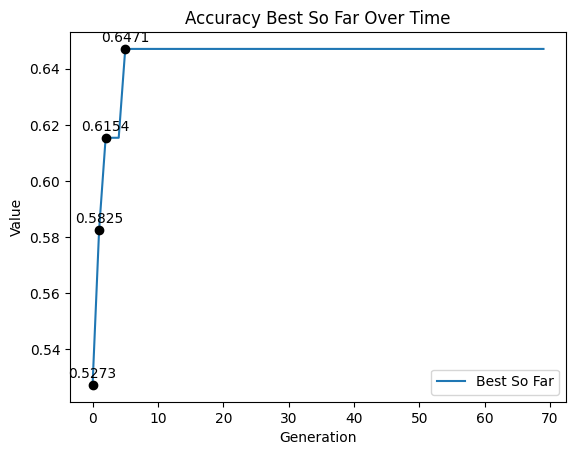

In [122]:
import json
import matplotlib.pyplot as plt

accs = []
evs = []
best_so_far = []  # 用來儲存每個世代中目前最好的值

# 設定要顯示的最大代數
max_generations = 70
out_folder = "out_GA_twii/0701_0330_ynu_15pro/"

with open(f"{out_folder}generation_results.json", 'r') as f:
    content = f.readlines()
    current_best = float('-inf')  # 初始化為最小值
    for i, line in enumerate(content):
        if i >= max_generations:  # 超過最大代數後停止
            break
        result = json.loads(line)
        acc = result['best_fitness']
        accs.append(acc)
        
        # 計算best so far
        if acc > current_best:
            current_best = acc
        best_so_far.append(current_best)

# 繪圖
plt.plot(best_so_far, label='Best So Far')

# 標註數值變化的點並圈起來
for i in range(0, len(best_so_far)):
    if best_so_far[i] != best_so_far[i-1]:  # 只有變化點才標註
        plt.scatter(i, best_so_far[i], color='black', zorder=5)  # 圈出變化點
        plt.annotate(f'{best_so_far[i]:.4f}', (i, best_so_far[i]), textcoords="offset points", xytext=(0, 5), ha='center')

plt.title('Accuracy Best So Far Over Time')  # 添加標題
plt.xlabel('Generation')  # X軸標籤
plt.ylabel('Value')  # Y軸標籤
plt.legend()

plt.show()


## 計算使用的費用

In [144]:
import json

input_price = 0.075
output_price = 0.3

input_token = 0
output_token = 0
for i in range(121):
    with open(f"out_GA_twii/0701_03303/{i+1}.json", 'r') as f:
        data = json.load(f)
        output_data = data["output_data"]

        for date_str, result in output_data.items():
            input_token += result["token"]["input_tokens"]
            output_token += result["token"]["output_tokens"]
        # print(input_token, output_token)

print(f'token: input {input_token}, output {output_token}')
usd = (input_token/1000000)*input_price + (output_token/1000000)*output_price
print(f'預估費用 {usd} USD, {usd*32.6} TWD')

token: input 13008837, output 3458561
預估費用 2.013231075 USD, 65.631333045 TWD
